*0324(월) 4주차 과제*\
*파이썬 머신러닝 완벽 가이드 8장 텍스트 분석 p.488-508*

> **NLP vs 텍스트 분석**

- NLP
 - 머신이 인간의 언어를 이해 & 해석
 - 텍스트 분석을 발전시키는 기반 기술

- 텍스트 분석(텍스트 마이닝)
 - 비정형 텍스트에서 의미 있는 정보 추출
 - 머신러닝, 언어 이해, 통계 등 활용

**텍스트 분석의 기술 영역**

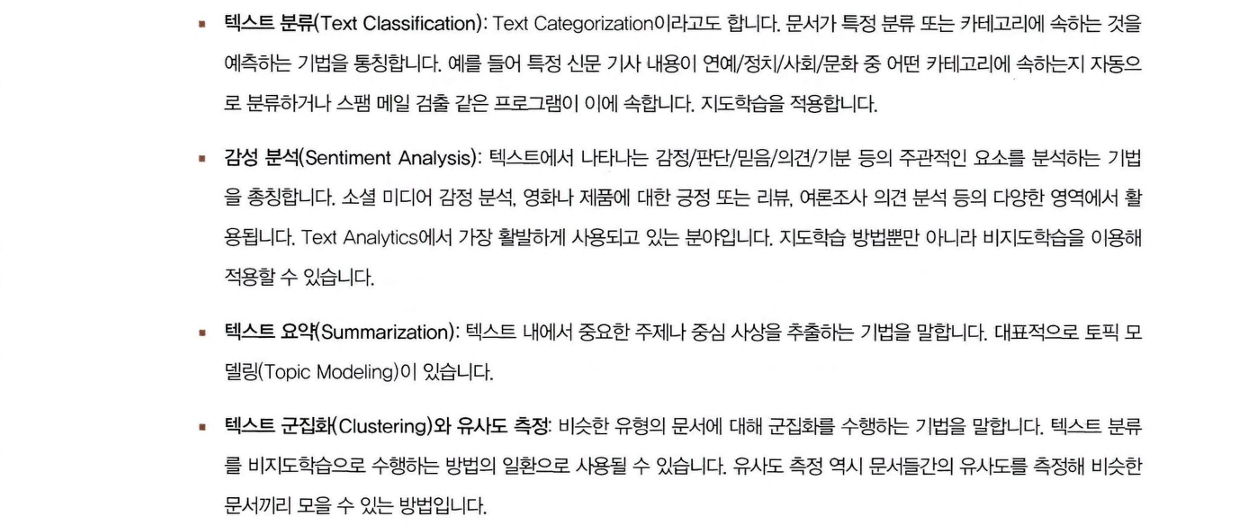

# 01. 텍스트 분석 이해

**텍스트 분석**
- 비정형 데이터인 텍스트를 분석하는 것

**피처 벡터화(피처 추출)**
- 텍스트를 word 기반의 다수의 피처로 추출
- 이에 단어 빈도수와 같은 숫자값을 부여
- 텍스트는 단어의 조합인 벡터값으로 표현 가능

**피처 벡터화 방법**
- BOW(Bag of Words)
- Word2Vec

> **텍스트 분석 수행 프로세스**

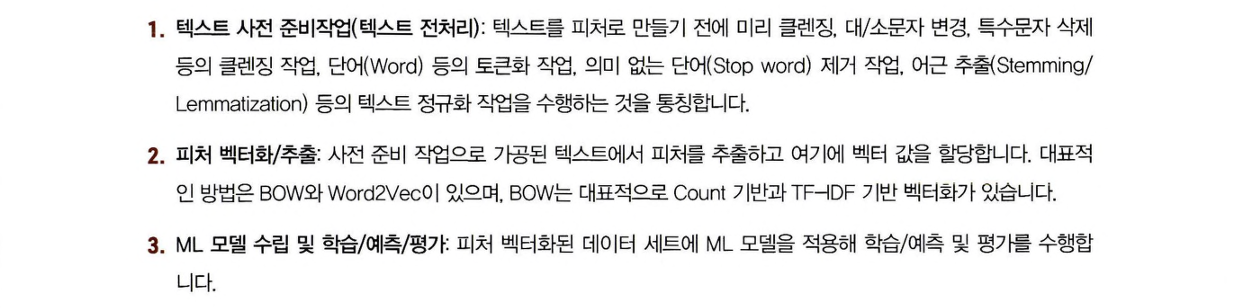

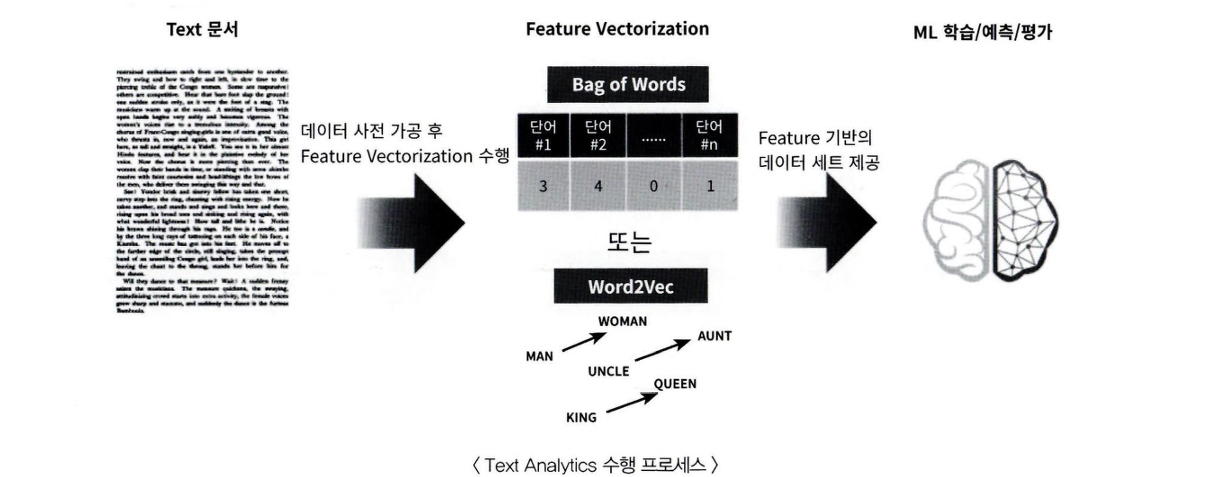

> **파이썬 기반의 NLP, 텍스트 분석 패키지**

- NLTK
- Genism
- SpaCy

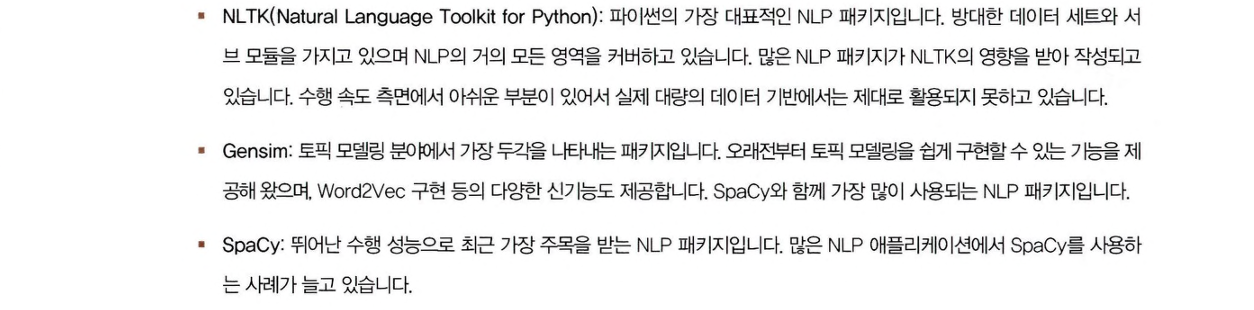

# 02. 텍스트 전처리 - 텍스트 정규화

**텍스트 정규화**
- 텍스트를 머신러닝 알고리즘이나 NLP 애플리케이션에 입력 데이터로 사용하기 위해 사전 작업을 수행하는 것
- 작업 분류
 - 클렌징
 - 토큰화
 - 필터링 / 스톱 워드 제거 / 철자 수정
 - Stemming
 - Lemmatization

> **클렌징**
- 불필요한 문자, 기호 등 사전에 제거
- HTML, XML 태그나 특정 기호 등

> **텍스트 토큰화**

- 문장 토큰화
 - 문장의 마침표, 개행문자 등 문장의 마지막을 의미하는 기호에 따라 분리
 - 정규 표현식에 따라 분리하는 것도 가능

In [18]:
# 문장 토큰화
#  3개의 문장으로 이루어진 텍스트 문서를 문장으로 각각 분리하는 예제

from nltk import sent_tokenize
import nltk
nltk.download('punkt_tab') # 마침표, 개행문자 등 데이터 다운받음
nltk.download('punkt')

text_sample = 'The matrix is everywhere its all around us, here even in this room. \
    You can see it out your window or on your television. \
    You feel it when you go to work, or go to church or pay your taxes.'

sentences = sent_tokenize(text=text_sample)
print(type(sentences),len(sentences))
print(sentences)

<class 'list'> 3
['The matrix is everywhere its all around us, here even in this room.', 'You can see it out your window or on your television.', 'You feel it when you go to work, or go to church or pay your taxes.']


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


- 단어 토큰화
 - 문장을 단어로 토큰화
 - 공백, 콤마, 마침표, 개행문자 등으로 구분
 - 정규 표현식을 이용해 다양한 유형으로 토큰화 수행도 가능
 - Bag of Word와 같이 단어의 순서가 중요X -> 단어 토큰화만 사용해도 충분

In [19]:
# 단어 토큰화

from nltk import word_tokenize

sentence = "The Matrix is everywhere its all around us, here even in this room."
words = word_tokenize(sentence)
print(type(words), len(words))
print(words)

<class 'list'> 15
['The', 'Matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.']


In [20]:
# sent_tokenize와 word_tokenize를 조합해 문서에 대해서 모든 단어를 토큰화

from nltk import word_tokenize, sent_tokenize

# 여러 개의 문장으로 된 입력 데이터를 문장별로 단어 토큰화하는 함수 생성
def tokenize_text(text):
    sentences = sent_tokenize(text) # 문장별 분리
    word_tokens = [word_tokenize(sentence) for sentence in sentences] # 분리된 문장별 단어 토큰화
    return word_tokens

# 여러 문장에 대해 문장별 단어 토큰화 수행
word_tokens = tokenize_text(text_sample)
print(type(word_tokens), len(word_tokens))
print(word_tokens)

<class 'list'> 3
[['The', 'matrix', 'is', 'everywhere', 'its', 'all', 'around', 'us', ',', 'here', 'even', 'in', 'this', 'room', '.'], ['You', 'can', 'see', 'it', 'out', 'your', 'window', 'or', 'on', 'your', 'television', '.'], ['You', 'feel', 'it', 'when', 'you', 'go', 'to', 'work', ',', 'or', 'go', 'to', 'church', 'or', 'pay', 'your', 'taxes', '.']]


- 3개의 문장이므로 3개의 리스트 객체를 내포하는 리스트
- 개별 리스트 객체는 각각 문장별로 토큰화된 단어를 요소로 가짐

**문장을 단어별로 토큰화할 때 문제점**
- 문맥적인 의미가 무시됨

**해결법**
- n-gram: 연속된 n개의 단어를 하나의 토큰화 단위로 분리
- n개 단어 크기 윈도우를 만들어 문장의 처음부터 오른쪽으로 움직이면서 토큰화를 수행함.
- 예시
  - "Agent Smith knocks the door"를 2—gram(bigram)으로 만들면
  - (Agent, Smith), (Smith, knocks), (knocks, the), (the, door)와 같이 연속적으로 2개의 단어들을 순차적으로 이동하면서 단어들을 토큰화함.

> **스톱 워드 제거**

**스톱 워드(Stop Word)**
- 분석에 큰 의미가 없는 단어
- 영어에서 is, the, a, will 등
- 사전에 제거해야 함

In [21]:
# NLTK의 스톱 워드 확인

# NLTK stopwords 목록 다운
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
# 영어에서 스톱워드 몇개인지 확인
print('영어 stop words 개수:', len(nltk.corpus.stopwords.words('english')))

영어 stop words 개수: 198


In [23]:
# 20개만 확인
print(nltk.corpus.stopwords.words('english')[:20])

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']


- NLTK에서 영어의 stop words 개수는 198개이다.
- 20개만 확인하면 다음과 같다

In [24]:
# 위 예제에서 3개의 문장별로 단어 토큰화한 리스트에 대해 스톱워드 필터링

import nltk

stopwords = nltk.corpus.stopwords.words('english')
all_tokens = []

# 위 예제에서 3개의 문장별로 얻은 word_tokens list에 대해 스톱워드를 제거하는 반복문
for sentence in word_tokens:
    filtered_word = []
    for word in sentence:
        # 소문자로 변환
        word = word.lower()
        # 토큰화된 단어가 스톱워드에 포함되지 않으면 word_tokens에 추가
        if word not in stopwords:
            filtered_word.append(word)
    all_tokens.append(filtered_word)

print(all_tokens)

[['matrix', 'everywhere', 'around', 'us', ',', 'even', 'room', '.'], ['see', 'window', 'television', '.'], ['feel', 'go', 'work', ',', 'go', 'church', 'pay', 'taxes', '.']]


- in. this 등이 제거됨

> **Stemming과 Lemmatization**

**Stemming, Lemmatization**
- 문법적, 의미적으로 변화한 단어의 원형을 찾음
- Stemming
 - 원형 단어로 변환 시 일반적인 or 더 단순화된 방법을 적용해 원래 단어에서 일부 철자가 훼손된 어근 단어를 추출하는 경향이 있음

- Lemmatization
 - Stemming보다 정교함
 - 품사와 같은 문법적인 요소와 더 의미적인 부분을 감안해 정확한 철자로 된 어근 단어를 찾음
 - Stemming보다 변환에 더 오랜 시간이 걸림

In [25]:
# NLTK의 LancasterStemmer를 이용해 Stemmer 살펴보기

# LancasterStemmer()와 같이 필요한 Stemmer 객체를 생성한 뒤
# 이 객체의 stem('단어') 메서드를 호출하면 원하는 '단어'의 Stemming이 가능함

from nltk.stem import LancasterStemmer
stemmer = LancasterStemmer()

print(stemmer.stem('working'), stemmer.stem('works'), stemmer.stem('worked'))
print(stemmer.stem('amusing'), stemmer.stem('amuses'), stemmer.stem('amused'))
print(stemmer.stem('happier'), stemmer.stem('happiest'))
print(stemmer.stem('fancier'), stemmer.stem('fanciest'))

work work work
amus amus amus
happy happiest
fant fanciest


**결과**
- work
 - 기본 단어인 work에 ing, s, ed가 붙는 단순한 변화이므로 원형 단어로 work를 제대로 인식함.

- amuse
 -  amus에 ing, s, ed가 붙으므로 정확한 단어인 amuse가 아닌 amus를 원형 단어로 인식함.

- 형용사인 happy, fancy
 - 정확한 원형을 찾지 못하고 원형 단어에서 철자가 다른 어근 단어로 인식하는 경우가 발생함.

In [26]:
# WordNetLemmatizer를 이용해 Lemmatization을 수행
# 정확한 원형 단어 추출을 위해 단어의 '품사'를 입력해야함.

from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')

lemma = WordNetLemmatizer()
print(lemma.lemmatize('amusing', 'v'), lemma.lemmatize('amuses', 'v'), lemma.lemmatize('amused', 'v'))
print(lemma.lemmatize('happier', 'a'), lemma.lemmatize('happiest', 'a'))
print(lemma.lemmatize('fancier', 'a'), lemma.lemmatize('fanciest', 'a'))

amuse amuse amuse
happy happy
fancy fancy


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**결과**
- 앞의 Stemmer보다 정확하게 원형 단어를 추출해줌

# 03. Bag of Words - BOW

**Bag of Words**
- 문서가 가지는 모든 단어(Words)를 문맥이나 순서를 무시하고 일괄적으로 단어에 대해 빈도 값을 부여해 피처 값을 추출하는 모델

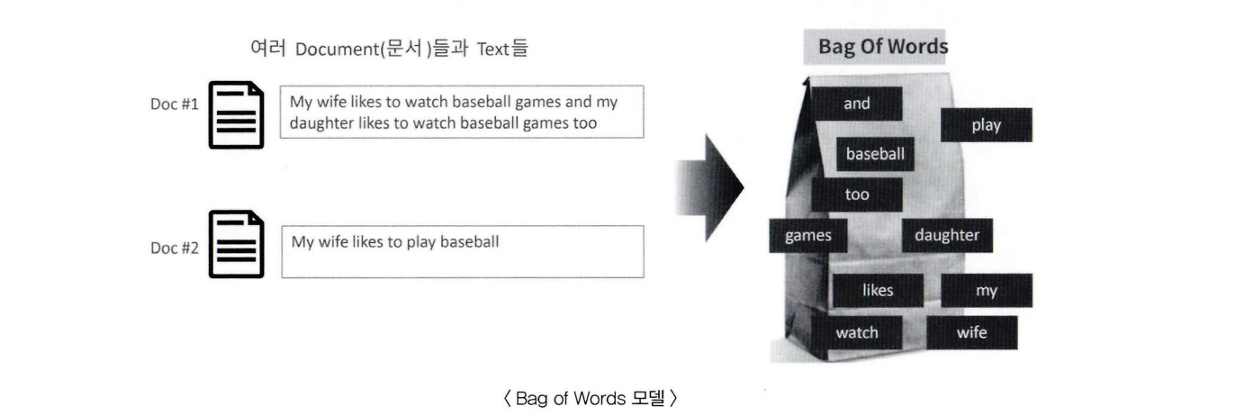

**2개의 문장을 BOW의 단어 수 기반으로 피처 추출**

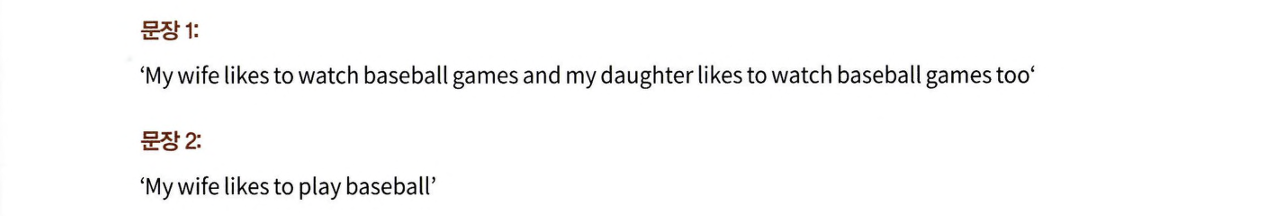

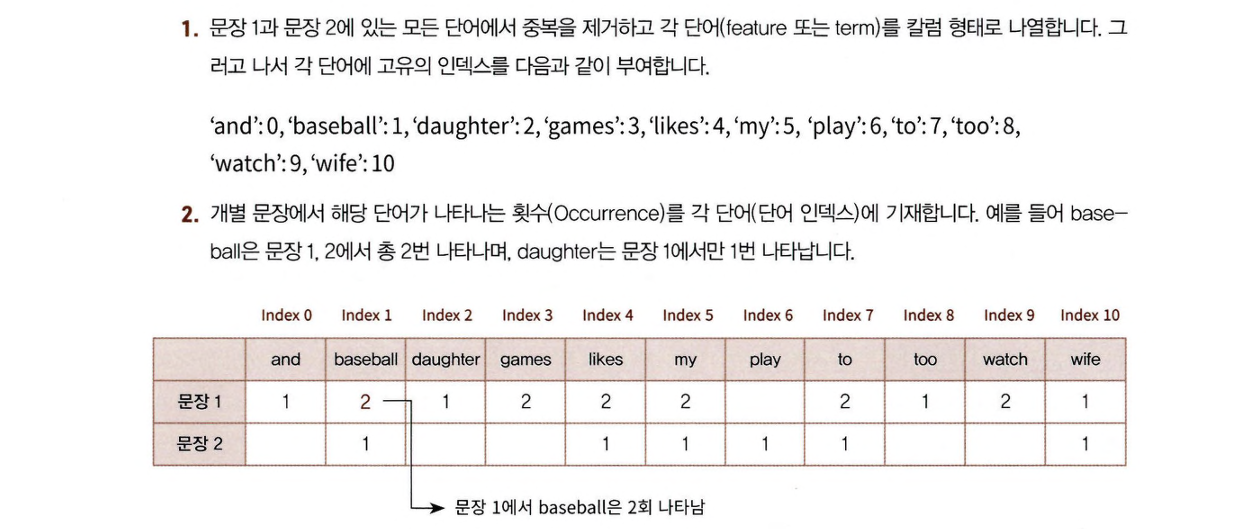

**BOW 모델의 장점**
- 쉽고 빠른 구축
- 문서의 특징을 잘 나타냄

**BOW 모델의 단점**
- 문맥 의미(Semantic Context) 반영 부족
 - 단어의 순서를 고려하지 않기 때문에 문장 내에서 단어의 문맥적인 의미가 무시됨
- 희소 행렬 문제(희소성, 희소 행렬)
 - BOW로 피처 벡터화를 수행하면 희소 행렬 형태의 데이터 세트가 만들어지기 쉬움. 희소 행렬은 일반적으로 ML 알고리즘의 수행 시간과 예측 성능을 떨어뜨림.

---

- 희소 행렬(Sparse Matrix): 대규모의 칼럼으로 구성된 행렬에서 대부분의 값이 0으로 채워자는 행렬.
- 밀집 행렬(Dense Matrix): 이와는 반대로 대부분의 값이 0이 아닌 의미 있는 값으로 채워져 있는 행렬.

> **BOW 피처 벡터화**

**피처 벡터화**
-  텍스트와 같은 데이터는 머신러닝 알고리즘에 바로 입력할 수가 없음
- 따라서 텍스트 -> 특정 의미를 가지는 숫자형 값인 벡터 값으로 변환하는 것

**BOW 모델에서 피처 벡터화를 수행한다는 것**
- 모든 문서에서 모든 단어를 칼럼 형태로 나열하고 각 문서에서 해당 단어의 횟수나 정규화된 빈도를 값으로 부여하는 데이터 세트 모델로 변경함.
- ex. M개의 텍스트 문서가 있고, 이 문서에서 모든 단어를 추출해 나열했을 때 N개의 단어가 있다고 가정
 - 문서의 피처 벡터화를 수행하면 M개의 문서는 각각 N개의 값이 할당된 피처의 벡터 세트가 됨.
 - 결과적으로는 M * N개의 단어 피처로 이뤄진 행렬을 구성하게 됨

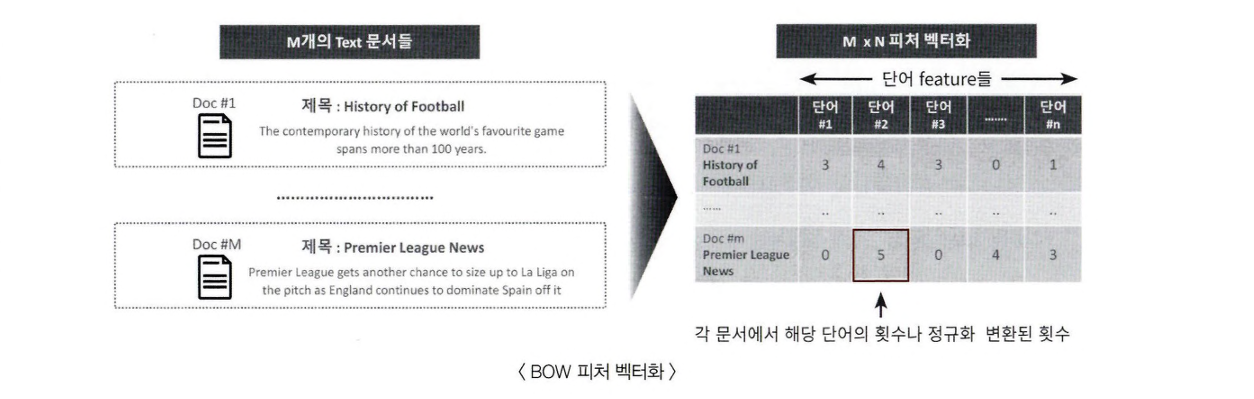

**BOW 피처 벡터화의 두 가지 방식**
- 카운트 기반의 벡터화
 - 단어 피처에 값을 부여할 때 각 문서에서 해당 단어가 나타나는 횟수, 즉 Count를 부여하는 경우
 - 카운트 벡터화에서는 카운트 값이 높을수록 중요한 단어로 인식됨.
 - 특징을 나타내기보다는 언어의 특성상 문장에서 자주 사용될 수밖에 없는 단어까지 높은 값을 부여하게 됨 -> TF-IDF에서 보완
- TF-IDF 기반 벡터화
 - 개별 문서에서 자주 나타나는 단어에 높은 가중치를 주되, 모든 문서에서 전반적으로 자주 나타나는 단어에 대해서는 페널티를 주는 방식으로 값을 부여함.

-> 문서마다 텍스트가 길고 문서의 개수가 많은 경우, 카운트 방식보다는 TF-IDF 방식이 굿.

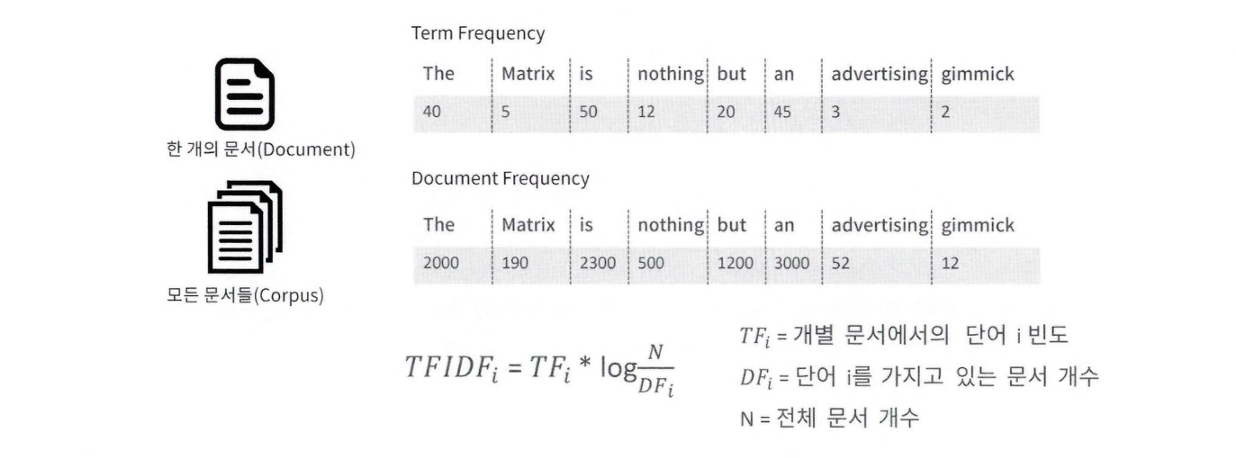

> **사이킷런의 Count 및 TF-IDF 벡터화 구현: CountVectorizer, TfidfVectorizer**

**사이킷런의 CountVectorizer 클래스**
- 피처 벡터화, 소문자 일괄 변환, 토큰화, 스톱 워드 필터링 등의 텍스트 전처리도 함께 수행함.
- fit()과 transform()을 통해 피처 벡터화된 객체를 반환함.

**CountVectorizer의 입력 파라미터**

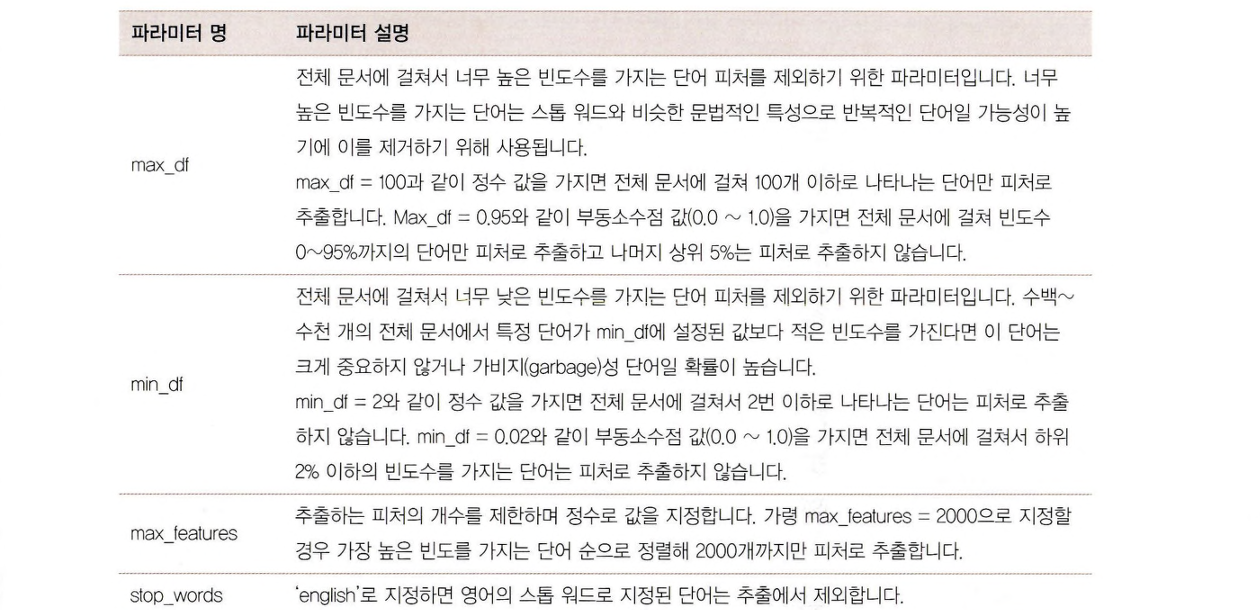

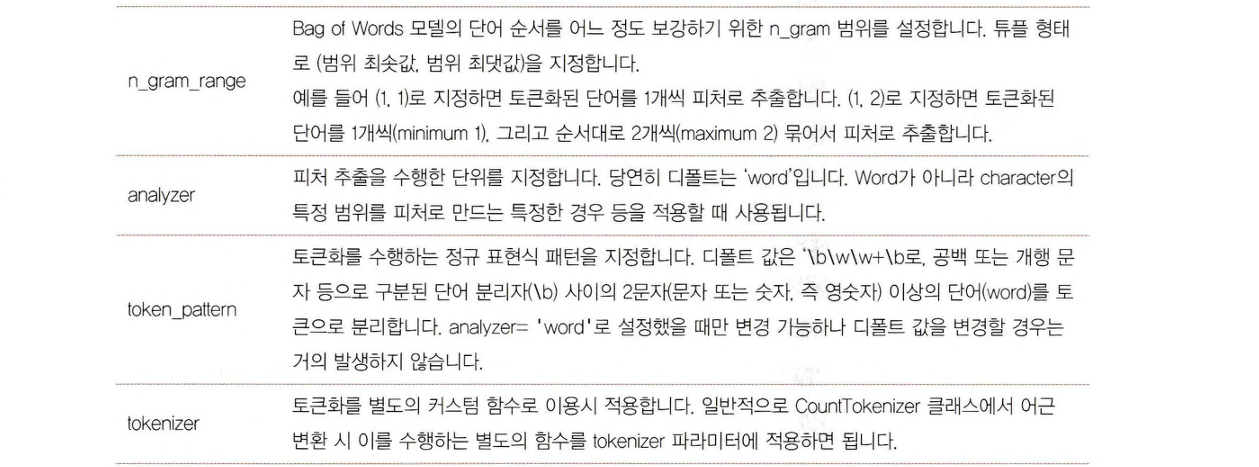

**사이킷런의 CountVectorizer 클래스를 이용한 피처 벡터화 방법**

1. 영어의 경우 모든 문자를 소문자로 변경하는 등의 전처리 작업을 수행.
2. 디폴트로 단어 기준으로 n_gram_range를 반영해 각 단어를 토큰화.
3. 텍스트 정규화 수행.

---

- 사이킷런에서 TF-IDF 벡터화는 TfidfVectorizer 클래스를 이용.
- 파라미터와 변환 방법은 CountVectorizer와 동일

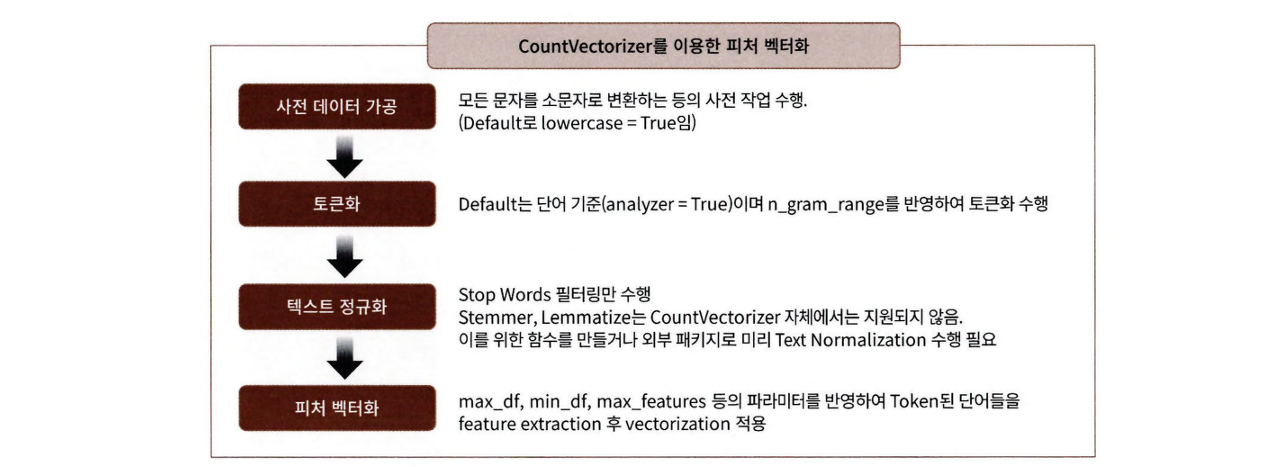

> **BOW 벡터화를 위한 희소 행렬**

- BOW 형태를 가진 언어 모델의 피처 벡터화는 대부분 희소 행렬임.
- 희소 행렬: 대규모 행렬의 대부분의 값을 0이 차지하는 행렬

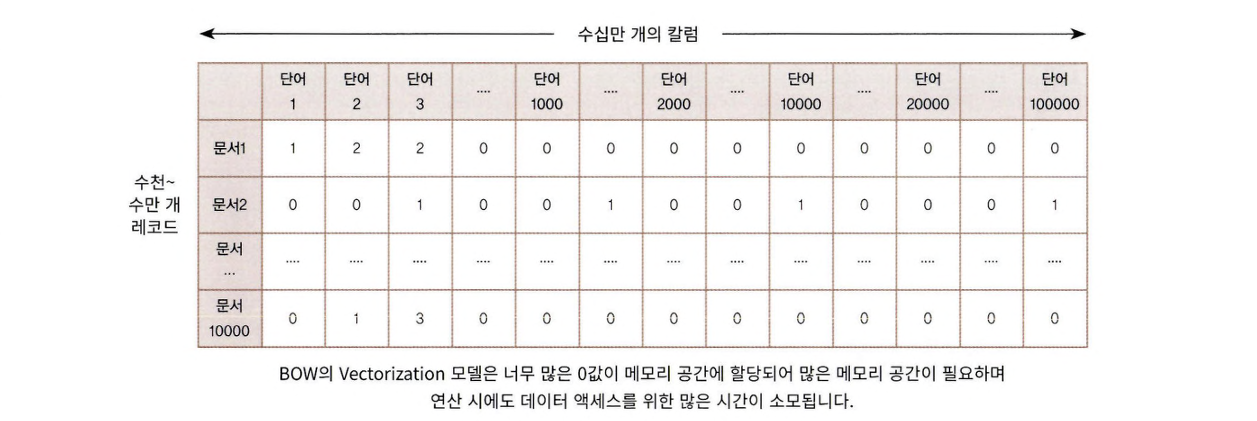

**희소 행렬 단점**
- 너무 많은 불필요한 0 값이 메모리 공간에 할당되어 메모리 공간이 많이 필요함
- 행렬의 크기가 커서 연산 시에도 데이터 액세스를 위한 시간이 많이 소모됨.

**변환 방법**
- 따라서 물리적으로 적은 메모리 공간을 차지할 수 있도록 변환해야 함
- 대표적인 방법
 - COO 형식
 - CSR 형식: 일반적으로 큰 희소 행렬을 저장하고 계산을 수행하는 능력이 CSR 형식이 더 뛰어나기 때문에 CSR을 많이 사용함.

> **희소 행렬 - COO 형식**

- COO(Coordinate: 좌표) 형식
 - 0이 아닌 데이터만 별도의 데이터 배열(Array)에 저장하고, 그 데이터가 가리키는 행과 열의 위치를 별도의 배열로 저장하는 방식
 - 예시
   - 2차원 데이터 [ [3, 0, 1], [0, 2, 0] ] 가정
   - 0이 아닌 데이터는 [3, 1, 2]이며 0이 아닌 데이터가 있는 위치를 (row, col)로 표시하면 (0,0),(0,2),(1,1).
   - 로우와 칼럼을 별도의 배열로 저장하면
로우는 [0, 0, 1]이고 칼럼은 [0, 2, 1].

In [27]:
# 사이파이의 sparse를 이용해 희소 행렬 변환 - COO 형식

import numpy as np

# [ [3, 0, 1], [0, 2, 0 ] ]을 넘파이의 ndarray 객체로 만듦
dense = np.array([ [3,0,1], [0,2,0] ])

In [28]:
# 위 밀집 행렬을 사이파이의 coo_matrix 클래스를 이용해 COO 형식의 희소 행렬로 변환

from scipy import sparse

# 0이 아닌 데이터 추출
data = np.array([3,1,2])

# 행 위치, 열 위치를 각각 배열로 생성
row_pos = np.array([0,0,1])
col_pos = np.array([0,2,1])

# sparse 패키지의 coo_matrix로 COO형식 희소행렬 생성
sparse_coo = sparse.coo_matrix((data, (row_pos, col_pos)))

In [29]:
# COO 형식의 희소 행렬 객체 변수인 sparse_coo
# toarray() 메서드를 이용해 다시 밀집 형태의 행렬로 출력

sparse_coo.toarray()

array([[3, 0, 1],
       [0, 2, 0]])

-> 다시 원래의 데이터 행렬로 추출됨

> **희소 행렬 - CSR 형식**

- CSR(Compressed Sparse Row) 형식
 - COO 형식이 행과 열의 위치를 나타내기 위해서 반복적인
위치 데이터를 사용해야 하는 문제점을 해결한 방식.
 - 행 위치 배열 내에 있는 고유한 값의 시작 위치만 다시 별도의 위치 배열로 가지는 변환 방식

**COO 변환 형식의 문제점 알아보기 - 2차원 배열을 COO 형식으로 변환**

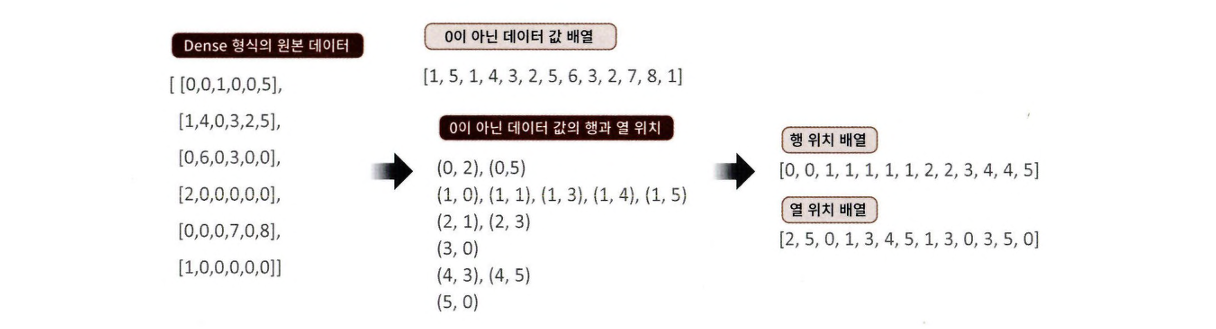

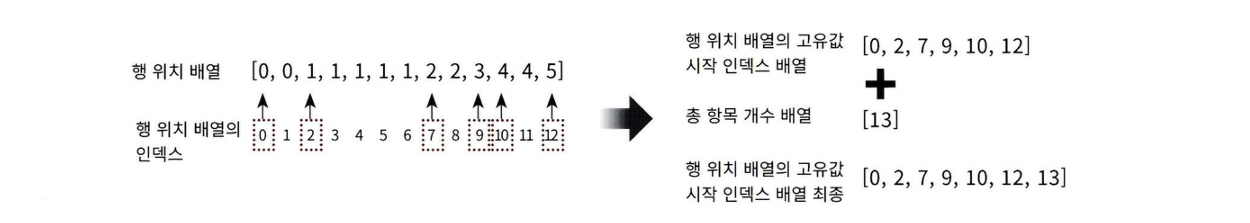

- 행 위치 배열 [0, 0, 1, 1, 1, 1, 1, 2, 2, 3, 4, 4, 5]를 CSR로 변환하면 [0, 2, 7, 9, 10, 12]가 됨
- 맨 마지막에는 데이터의 총 항목 개수를 배열에 추가
- 최종적으로 **[0, 2, 7, 9, 10, 12, 13]**

-> 고유 값의 시작 위치만 알고 있으면 얼마든지 행 위치
배열을 다시 만들 수 있기에 COO 방식보다 메모리가 적게 들고 빠른 연산이 가능함.

In [30]:
# 사이파이의 csr_matrix 클래스를 이용해 CSR 방식의 변환

from scipy import sparse

dense2 = np.array([[0,0,1,0,0,5],
                  [1,4,0,3,2,5],
                  [0,6,0,3,0,0],
                  [2,0,0,0,0,0],
                  [0,0,0,7,0,8],
                  [1,0,0,0,0,0]])

# 0이 아닌 데이터 추출
data2 = np.array([1,5,1,4,3,2,5,6,3,2,7,8,1])

# 행 위치와 열 위치를 각각 array로 생성
row_pos = np.array([0,0,1,1,1,1,1,2,2,3,4,4,5])
col_pos = np.array([2,5,0,1,3,4,5,1,3,0,3,5,0])

# COO형식으로 변환
sparse_coo = sparse.coo_matrix((data2, (row_pos, col_pos)))

# 행 위치 배열의 고유한 값의 시작 위치 인덱스를 배열로 생성
row_pos_ind = np.array([0,2,7,9,10,12,13])

# CSR방식으로 변환
sparse_csr = sparse.csr_matrix((data2, col_pos, row_pos_ind))

print('COO 변환된 데이터가 제대로 되었는지 확인')
print(sparse_coo.toarray())
print('CSR 변환된 데이터가 제대로 되었는지 확인')
print(sparse_csr.toarray())

COO 변환된 데이터가 제대로 되었는지 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]
CSR 변환된 데이터가 제대로 되었는지 확인
[[0 0 1 0 0 5]
 [1 4 0 3 2 5]
 [0 6 0 3 0 0]
 [2 0 0 0 0 0]
 [0 0 0 7 0 8]
 [1 0 0 0 0 0]]


In [31]:
# 실제 사용 시에는 다음과 같이 밀집 행렬을 생성 파라미터로 입력하면 COO나 CSR 희소 행렬로 생성

dense3 = np.array([[0,0,1,0,0,5],
                  [1,4,0,3,2,5],
                  [0,6,0,3,0,0],
                  [2,0,0,0,0,0],
                  [0,0,0,7,0,8],
                  [1,0,0,0,0,0]])

coo = sparse.coo_matrix(dense3)
csr = sparse.csr_matrix(dense3)